# Wstępna analiza statystyczna: dane GDELT

Ten notebook zawiera wstępną analizę statystyczną dziennych cech GDELT w uzupełnionym zbiorze:
- wczytanie i walidację danych,
- kontrolę jakości danych,
- statystyki opisowe,
- wizualizacje rozkładów i wzorców czasowych,
- diagnostykę autokorelacji.

In [22]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 10

In [23]:
data_candidates = [
    Path("../data/equity_data/gdelt_data_dailt_filled.csv"),
    Path("../data/equity_data/gdelt_data_daily_filled.csv"),
    Path("data/equity_data/gdelt_data_dailt_filled.csv"),
    Path("data/equity_data/gdelt_data_daily_filled.csv"),
]

data_path = next((p for p in data_candidates if p.exists()), None)
if data_path is None:
    raise FileNotFoundError("Nie znaleziono wypełnionego pliku CSV GDELT z bieżącego katalogu roboczego.")

df = pd.read_csv(data_path)

date_col = "Date" if "Date" in df.columns else ("date" if "date" in df.columns else None)
if date_col is None:
    raise ValueError("Nie znaleziono kolumny z datą. Oczekiwano `Date` lub `date`.")

if date_col != "Date":
    df = df.rename(columns={date_col: "Date"})

numeric_cols = [c for c in df.columns if c != "Date"]
derived_cols = [c for c in ["gdelt_robust"] if c in numeric_cols]
original_cols = [c for c in numeric_cols if c not in derived_cols]
plot_cols = original_cols if len(original_cols) > 0 else numeric_cols

df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.sort_values("Date").reset_index(drop=True)

print(f"Źródło danych: {data_path}")
print(f"Liczba wierszy: {len(df):,}, liczba kolumn: {len(df.columns)}")
print(f"Zmienne numeryczne: {numeric_cols}")
print(f"Zmienne oryginalne: {original_cols}")
print(f"Zmienne pochodne: {derived_cols}")
display(df.head())

Źródło danych: ..\data\equity_data\gdelt_data_daily_filled.csv
Liczba wierszy: 1,097, liczba kolumn: 4
Zmienne numeryczne: ['gdelt_articles', 'gdelt_robust', 'sentiment_score']
Zmienne oryginalne: ['gdelt_articles', 'sentiment_score']
Zmienne pochodne: ['gdelt_robust']


,Date,gdelt_articles,gdelt_robust,sentiment_score
0,2023-01-01,0.3065,-0.224062,-0.9249
1,2023-01-02,0.4465,0.548565,-0.7794
2,2023-01-03,0.8445,2.745033,-0.9603
3,2023-01-04,0.8318,2.674945,-1.7953
4,2023-01-05,0.5053,0.873068,-1.3037


In [24]:
quality_report = pd.DataFrame(
    {
        "dtype": df.dtypes.astype(str),
        "missing_values": df.isna().sum(),
        "missing_pct": (df.isna().mean() * 100).round(2),
        "unique_values": df.nunique(dropna=True),
    }
)

date_range = (df["Date"].min(), df["Date"].max())
duplicate_rows = int(df.duplicated().sum())
duplicate_dates = int(df["Date"].duplicated().sum())

full_calendar = pd.date_range(start=date_range[0], end=date_range[1], freq="D")
missing_dates = full_calendar.difference(df["Date"].dropna())

display(quality_report)
print(f"Zakres dat: {date_range[0].date()} -> {date_range[1].date()}")
print(f"Zduplikowane wiersze: {duplicate_rows}")
print(f"Zduplikowane daty: {duplicate_dates}")
print(f"Brakujące dni kalendarzowe: {len(missing_dates)}")

if len(missing_dates) > 0:
    print("Pierwsze brakujące daty:", [d.date() for d in missing_dates[:10]])

,dtype,missing_values,missing_pct,unique_values
Date,datetime64[us],0,0.0,1097
gdelt_articles,float64,0,0.0,984
gdelt_robust,float64,0,0.0,987
sentiment_score,float64,0,0.0,1070


Zakres dat: 2023-01-01 -> 2026-01-01
Zduplikowane wiersze: 0
Zduplikowane daty: 0
Brakujące dni kalendarzowe: 0


In [25]:
percentiles = [0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]

def summarize(columns):
    base_stats = df[columns].describe(percentiles=percentiles).T
    extra_stats = pd.DataFrame(
        {
            "variance": df[columns].var(),
            "IQR": df[columns].quantile(0.75) - df[columns].quantile(0.25),
            "skewness": df[columns].skew(),
            "kurtosis": df[columns].kurt(),
            "coef_of_variation": df[columns].std() / df[columns].mean().replace(0, np.nan),
        }
    )
    return base_stats.join(extra_stats).round(4)

if len(original_cols) > 0:
    print("Zmienne oryginalne:")
    display(summarize(original_cols))

if len(derived_cols) > 0:
    print("Zmienne pochodne (wyliczone na podstawie oryginalnych):")
    display(summarize(derived_cols))

Zmienne oryginalne:


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,variance,IQR,skewness,kurtosis,coef_of_variation
gdelt_articles,1097.0,0.3940,0.1829,0.1552,0.1725,0.2030,0.2809,0.3577,0.4545,0.7224,0.9835,2.5457,0.0335,0.1736,3.4065,25.6810,0.4642
sentiment_score,1097.0,-0.3812,0.6336,-3.5467,-2.5255,-1.5485,-0.6766,-0.2938,0.0288,0.4702,0.8272,1.3550,0.4014,0.7054,-1.0658,2.1919,-1.6620


Zmienne pochodne (wyliczone na podstawie oryginalnych):


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,variance,IQR,skewness,kurtosis,coef_of_variation
gdelt_robust,1097.0,0.2591,1.0095,-1.0591,-0.9636,-0.7953,-0.3654,0.0585,0.5927,2.071,3.5119,12.1336,1.019,0.9581,3.4065,25.681,3.8963


,gdelt_articles,gdelt_robust,sentiment_score
gdelt_articles,1.0000,1.0000,-0.4689
gdelt_robust,1.0000,1.0000,-0.4689
sentiment_score,-0.4689,-0.4689,1.0000


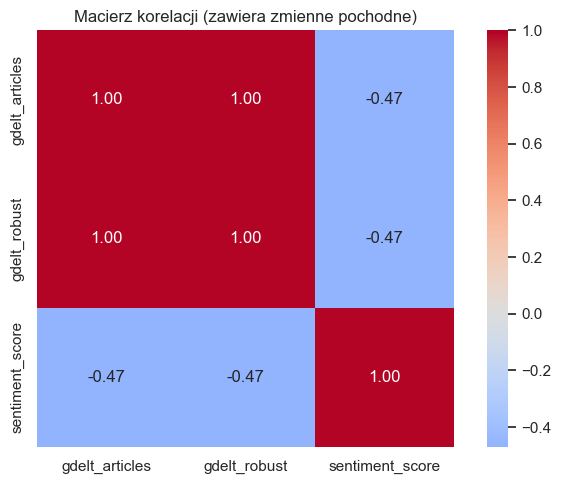

Kontrola spójności robust (maks. różnica bezwzględna): 0.46922509


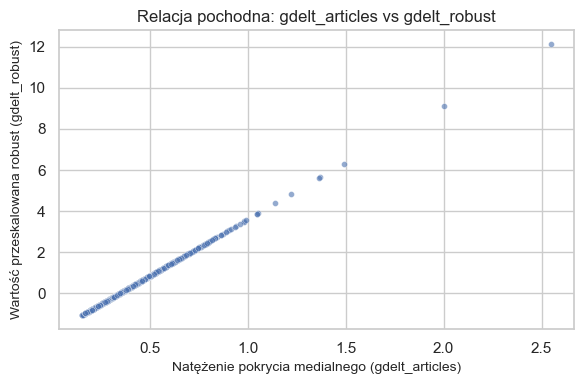

In [26]:
corr = df[numeric_cols].corr(method="pearson")
display(corr.round(4))

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Macierz korelacji (zawiera zmienne pochodne)")
plt.tight_layout()
plt.show()

if {"gdelt_articles", "gdelt_robust"}.issubset(df.columns):
    robust_median = df["gdelt_articles"].median()
    robust_iqr = df["gdelt_articles"].quantile(0.75) - df["gdelt_articles"].quantile(0.25)
    if robust_iqr != 0:
        reconstructed_robust = (df["gdelt_articles"] - robust_median) / robust_iqr
        max_abs_diff = (df["gdelt_robust"] - reconstructed_robust).abs().max()
        print(f"Kontrola spójności robust (maks. różnica bezwzględna): {max_abs_diff:.8f}")
    else:
        print("Pominięto kontrolę spójności robust: IQR = 0.")

    plt.figure(figsize=(6, 4))
    sns.scatterplot(data=df, x="gdelt_articles", y="gdelt_robust", s=18, alpha=0.6)
    plt.title("Relacja pochodna: gdelt_articles vs gdelt_robust")
    plt.xlabel("Natężenie pokrycia medialnego (gdelt_articles)")
    plt.ylabel("Wartość przeskalowana robust (gdelt_robust)")
    plt.tight_layout()
    plt.show()

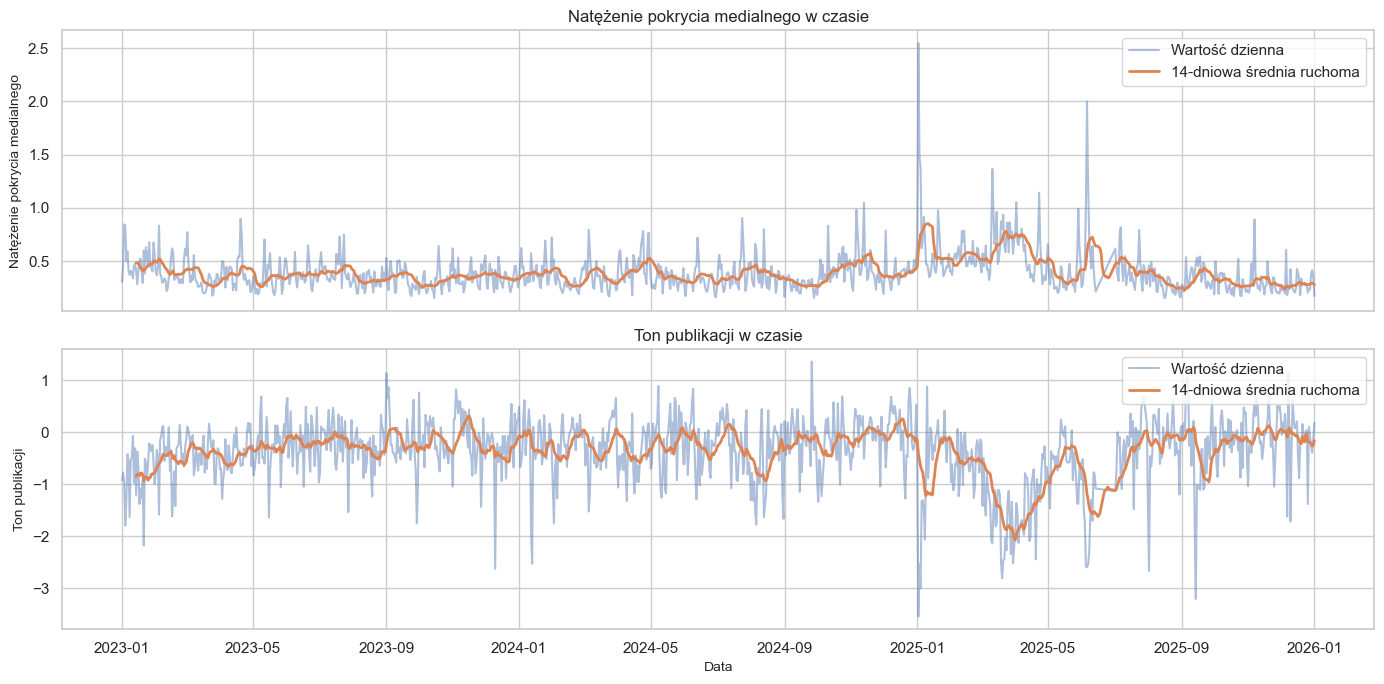

In [27]:
rolling_window = 14
rolling_means = df[plot_cols].rolling(rolling_window).mean()

label_map = {
    "gdelt_articles": "Natężenie pokrycia medialnego",
    "sentiment_score": "Ton publikacji",
    "gdelt_robust": "Przeskalowane natężenie pokrycia medialnego",
}

n = len(plot_cols)
fig, axes = plt.subplots(n, 1, figsize=(14, 3.5 * n), sharex=True)
if n == 1:
    axes = [axes]

for i, col in enumerate(plot_cols):
    ax = axes[i]
    display_name = label_map.get(col, col)

    ax.plot(df["Date"], df[col], alpha=0.45, label="Wartość dzienna")
    ax.plot(
        df["Date"],
        rolling_means[col],
        linewidth=2,
        label=f"{rolling_window}-dniowa średnia ruchoma"
    )
    ax.set_title(f"{display_name} w czasie")
    ax.set_ylabel(display_name)
    ax.legend(loc="upper right")

axes[-1].set_xlabel("Data")
plt.tight_layout()
plt.show()

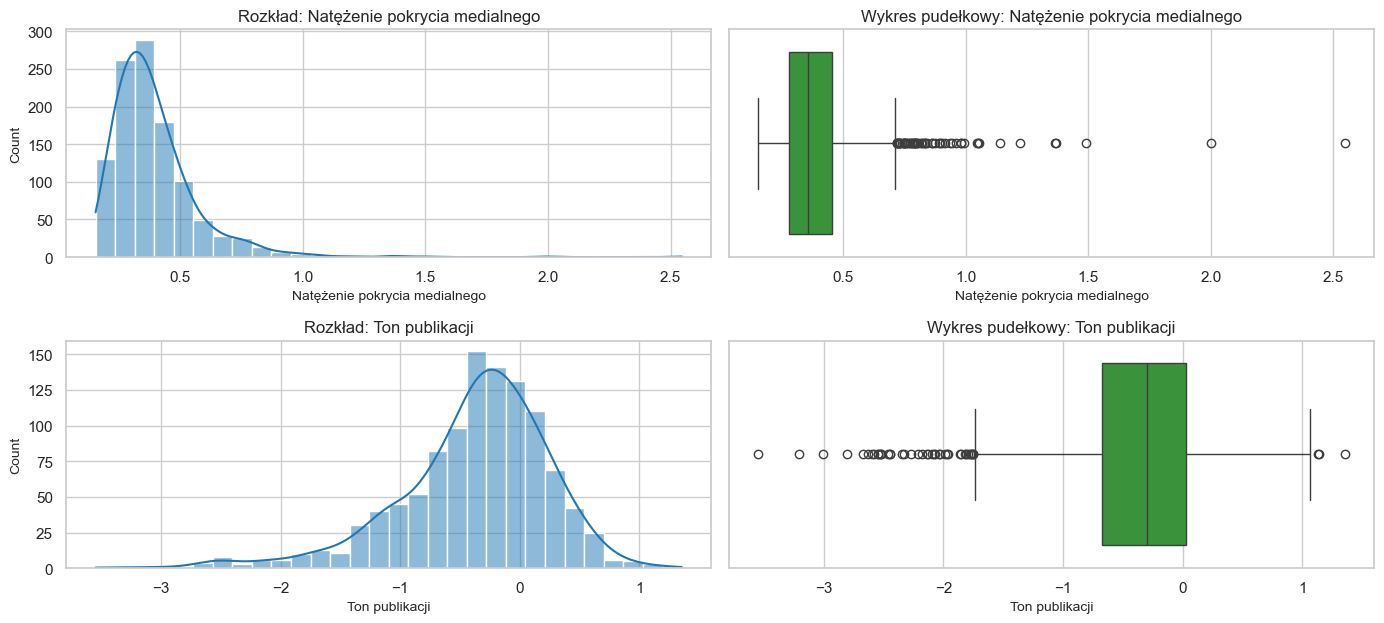

In [28]:
n = len(plot_cols)
fig, axes = plt.subplots(n, 2, figsize=(14, 3.2 * n))
if n == 1:
    axes = np.array([axes])

for i, col in enumerate(plot_cols):
    display_name = label_map.get(col, col)
    sns.histplot(df[col], bins=30, kde=True, ax=axes[i, 0], color="tab:blue")
    axes[i, 0].set_title(f"Rozkład: {display_name}")
    axes[i, 0].set_xlabel(display_name)

    sns.boxplot(x=df[col], ax=axes[i, 1], color="tab:green")
    axes[i, 1].set_title(f"Wykres pudełkowy: {display_name}")
    axes[i, 1].set_xlabel(display_name)

plt.tight_layout()
plt.show()

,gdelt_articles,sentiment_score
weekday,,
Poniedziałek,0.4022,-0.3134
Wtorek,0.4306,-0.4308
Środa,0.4392,-0.4048
Czwartek,0.4309,-0.3340
Piątek,0.4171,-0.3563
Sobota,0.3362,-0.4856
Niedziela,0.3019,-0.3440


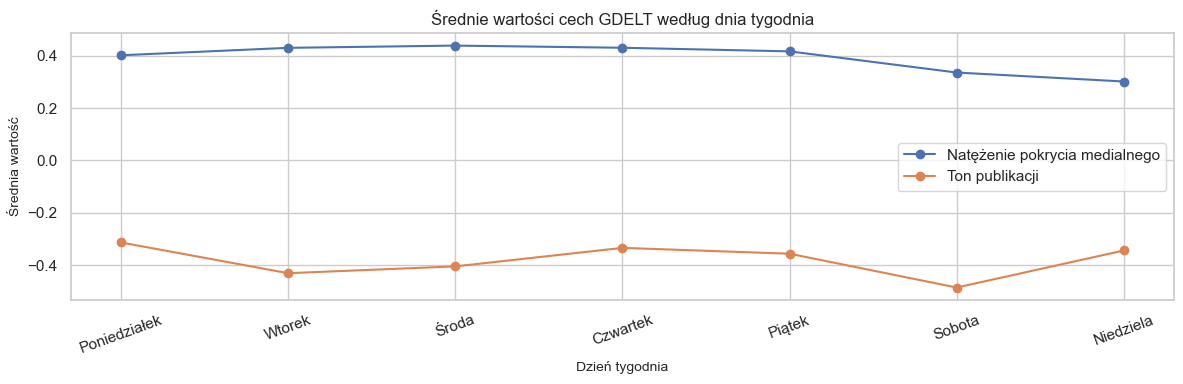

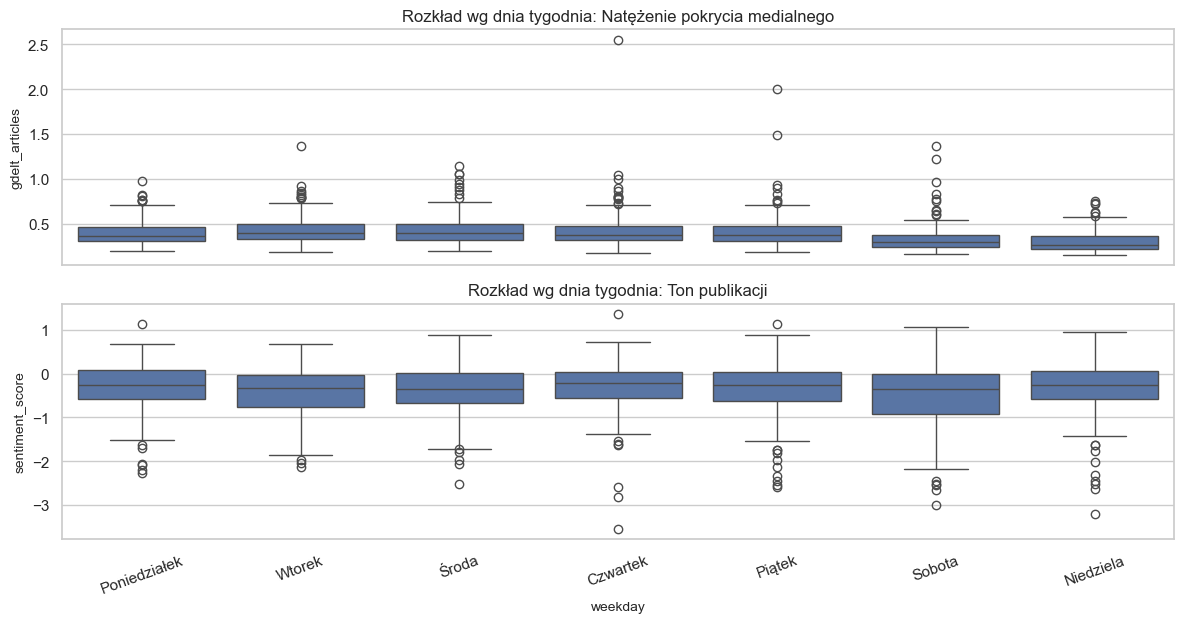

In [29]:
weekday_map = {
    "Monday": "Poniedziałek",
    "Tuesday": "Wtorek",
    "Wednesday": "Środa",
    "Thursday": "Czwartek",
    "Friday": "Piątek",
    "Saturday": "Sobota",
    "Sunday": "Niedziela",
}
weekday_order = ["Poniedziałek", "Wtorek", "Środa", "Czwartek", "Piątek", "Sobota", "Niedziela"]
df["weekday"] = df["Date"].dt.day_name().map(weekday_map)

weekday_summary = (
    df.groupby("weekday")[plot_cols]
    .mean()
    .reindex(weekday_order)
    .round(4)
)
display(weekday_summary)

plt.figure(figsize=(12, 4))
for col in plot_cols:
    plt.plot(weekday_summary.index, weekday_summary[col], marker="o", label=label_map.get(col, col))
plt.title("Średnie wartości cech GDELT według dnia tygodnia")
plt.xlabel("Dzień tygodnia")
plt.ylabel("Średnia wartość")
plt.xticks(rotation=20)
plt.legend()
plt.tight_layout()
plt.show()

n = len(plot_cols)
fig, axes = plt.subplots(n, 1, figsize=(12, 3.2 * n), sharex=True)
if n == 1:
    axes = [axes]

for i, col in enumerate(plot_cols):
    display_name = label_map.get(col, col)
    sns.boxplot(data=df, x="weekday", y=col, order=weekday_order, ax=axes[i])
    axes[i].set_title(f"Rozkład wg dnia tygodnia: {display_name}")
    axes[i].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

,gdelt_articles,sentiment_score
Date,,
2025-02-28,0.5431,-0.5824
2025-03-31,0.6741,-1.6299
2025-04-30,0.5611,-1.2774
2025-05-31,0.3699,-0.5387
2025-06-30,0.5158,-1.3244
2025-07-31,0.4299,-0.2167
2025-08-31,0.2861,-0.2545
2025-09-30,0.3585,-0.3668
2025-10-31,0.2889,-0.1414


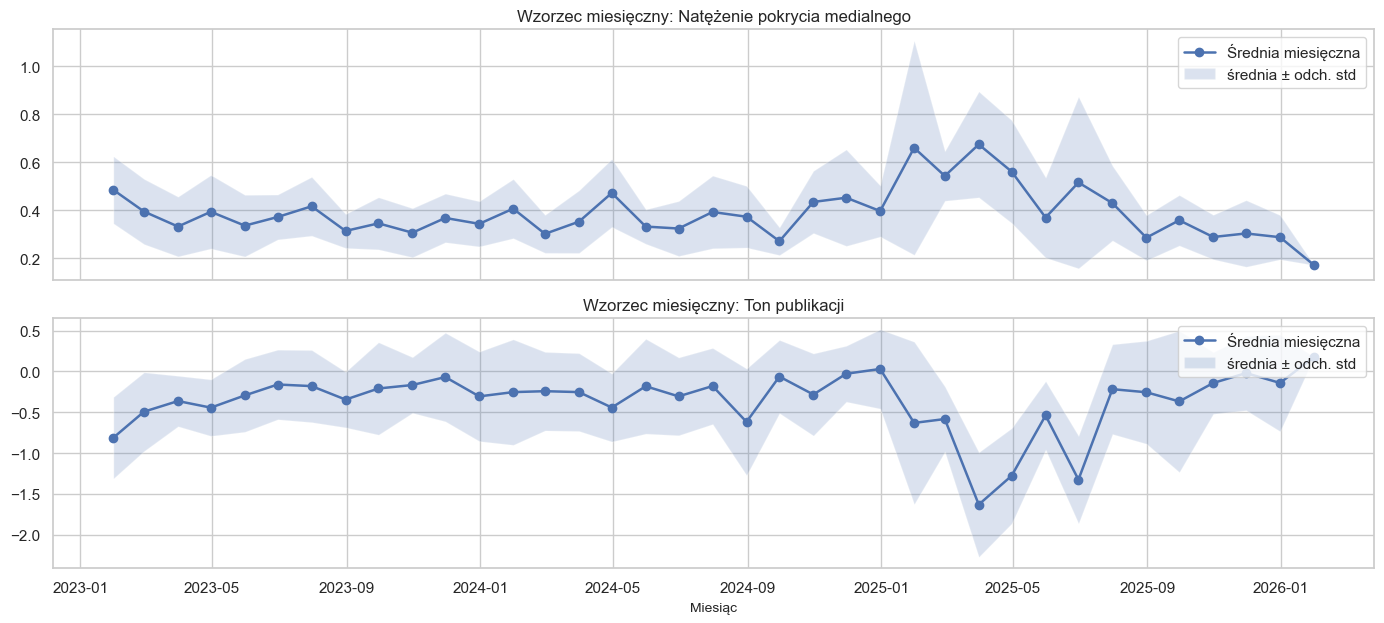

In [30]:
monthly_mean = df.set_index("Date")[plot_cols].resample("ME").mean()
monthly_std = df.set_index("Date")[plot_cols].resample("ME").std()

display(monthly_mean.tail(12).round(4))

n = len(plot_cols)
fig, axes = plt.subplots(n, 1, figsize=(14, 3.2 * n), sharex=True)
if n == 1:
    axes = [axes]

for i, col in enumerate(plot_cols):
    ax = axes[i]
    display_name = label_map.get(col, col)
    ax.plot(monthly_mean.index, monthly_mean[col], marker="o", linewidth=1.8, label="Średnia miesięczna")
    lower = monthly_mean[col] - monthly_std[col].fillna(0)
    upper = monthly_mean[col] + monthly_std[col].fillna(0)
    ax.fill_between(monthly_mean.index, lower, upper, alpha=0.2, label="średnia ± odch. std")
    ax.set_title(f"Wzorzec miesięczny: {display_name}")
    ax.legend(loc="upper right")

axes[-1].set_xlabel("Miesiąc")
plt.tight_layout()
plt.show()

,gdelt_articles,sentiment_score
opóźnienie,,
1,0.6277,0.5877
2,0.3841,0.3938
3,0.2644,0.3789
4,0.2545,0.3593
5,0.2478,0.3312
6,0.2763,0.2790
7,0.2967,0.2521
8,0.2502,0.2367
9,0.1877,0.2435


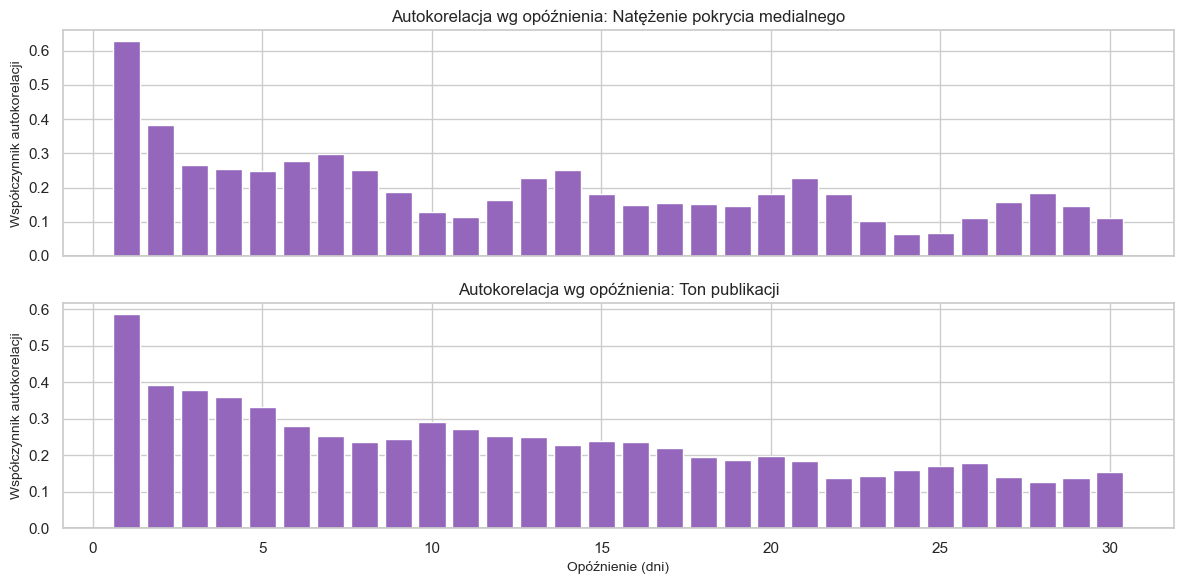

Podsumowanie pierwszych różnic (zmienne oryginalne):


,count,mean,std,min,25%,50%,75%,max
gdelt_articles,1096.0,-0.0001,0.1579,-1.0562,-0.0706,-0.0036,0.0697,1.8211
sentiment_score,1096.0,0.0010,0.5753,-2.9339,-0.2912,0.0033,0.3154,2.7658


Podsumowanie pierwszych różnic (zmienne pochodne):


,count,mean,std,min,25%,50%,75%,max
gdelt_robust,1096.0,-0.0007,0.8712,-5.8289,-0.3893,-0.0199,0.3845,10.0502


In [31]:
max_lag = 30
autocorr_table = pd.DataFrame(
    {
        col: [df[col].autocorr(lag=lag) for lag in range(1, max_lag + 1)]
        for col in plot_cols
    },
    index=range(1, max_lag + 1),
)
autocorr_table.index.name = "opóźnienie"

display(autocorr_table.head(10).round(4))

n = len(plot_cols)
fig, axes = plt.subplots(n, 1, figsize=(12, 3 * n), sharex=True)
if n == 1:
    axes = [axes]

for i, col in enumerate(plot_cols):
    ax = axes[i]
    display_name = label_map.get(col, col)
    ax.bar(autocorr_table.index, autocorr_table[col], color="tab:purple")
    ax.axhline(0, color="black", linewidth=1)
    ax.set_title(f"Autokorelacja wg opóźnienia: {display_name}")
    ax.set_ylabel("Współczynnik autokorelacji")

axes[-1].set_xlabel("Opóźnienie (dni)")
plt.tight_layout()
plt.show()

diff_summary = df[plot_cols].diff().describe().T.round(4)
print("Podsumowanie pierwszych różnic (zmienne oryginalne):")
display(diff_summary)

if len(derived_cols) > 0:
    derived_diff_summary = df[derived_cols].diff().describe().T.round(4)
    print("Podsumowanie pierwszych różnic (zmienne pochodne):")
    display(derived_diff_summary)

## Lista kontrolna interpretacji (wstępnej)

Po uruchomieniu wszystkich komórek podsumuj:
- czy szereg jest kompletny i czysty (braki dat, duplikaty, wartości puste),
- która oryginalna cecha ma największą zmienność i najsilniejsze wartości odstające,
- czy `gdelt_robust` jest spójne ze skalowaniem robust zmiennej `gdelt_articles`,
- czy widać sezonowość tygodniową lub miesięczną w którejkolwiek metryce,
- czy autokorelacja sugeruje krótką pamięć szeregu (przydatną dla cech opóźnionych).

To lekki notebook eksploracyjny, który można rozszerzyć o formalne testy stacjonarności i dekompozycję. W modelowaniu traktuj `gdelt_robust` jako zmienną pochodną od `gdelt_articles` i unikaj używania obu jako niezależnych sygnałów bez uzasadnienia.